In [ ]:
# Conectando com GitHub
!git config --global user.email "jesse_ombd@hotmail.com"
!git config --global user.name "Jesse-DataDriven"

# Clonando o repositório
!git clone https://github.com/Jesse-DataDriven/Generative-AI-Lab

Cloning into 'Generative-AI-Lab'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 32 (delta 8), reused 22 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 11.36 KiB | 2.84 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [ ]:
# Montando Google Drive para salvar progresso
from google.colab import drive
drive.mount('/content/drive')

# Criando pasta do projeto no Drive
import os
os.makedirs('/content/drive/MyDrive/Minha-IA-Generativa', exist_ok=True)
print("Drive conectado e pasta criada!")

Mounted at /content/drive
Drive conectado e pasta criada!


In [ ]:
# Dependências importantes
!pip install diffusers transformers accelerate xformers torch torchvision -q
!pip install deep-translator -q
!pip install pyngrok fastapi uvicorn nest-asyncio -q
!pip install xformers -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared
!chmod +x /usr/local/bin/cloudflared

import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler #StableDiffusionUpscalePipeline
from deep_translator import GoogleTranslator
from IPython.display import display

/usr/local/bin/cloudflared: Text file busy


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
!nvidia-smi

Mon Mar  2 21:55:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
#from diffusers import StableDiffusionPipeline
#import torch

# Carregando o SD 1.5 (mais leve e rápido)
#pipe = StableDiffusionPipeline.from_pretrained(
#    "runwayml/stable-diffusion-v1-5",
#    torch_dtype=torch.float16,  # float16 para economizar VRAM
#    safety_checker=None         # removendo o filtro de conteúdo
#)

#pipe = pipe.to("cuda")

# Otimizando a memória (T4)
#pipe.enable_xformers_memory_efficient_attention()
#print("Modelo carregado!")

In [ ]:
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None,
).to("cuda")

# Scheduler mais eficiente
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
#pipe.enable_xformers_memory_efficient_attention()

print("Modelo carregado!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Modelo carregado!


In [ ]:
print(pipe)

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "DPMSolverMultistepScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}



In [ ]:
import gc
print(type(pipe))
print("pipe OK!")

<class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'>
pipe OK!


In [ ]:
# prefix = "masterpiece, best quality, highly detailed, sharp focus, "
# negative_prompt = "ugly, deformed, noisy, blurry, distorted, out of focus, bad anatomy, extra limbs, poorly drawn face, poorly drawn hands, missing fingers"

# def gerar_imagem(prompt_pt):
#     prompt_en = prefix + traduzir_prompt(prompt_pt)
#     print(f"Traduzido: {prompt_en}")
#     image = pipe(
#         prompt=prompt_en,
#         negative_prompt=negative_prompt,
#         num_inference_steps=30,
#         guidance_scale=7.5,
#     ).images[0]
#     display(image)
#     return image

Traduzido: masterpiece, best quality, highly detailed, sharp focus, Create a spaceship pilot raccoon. He is flying his spaceship and passing by the earth. It is inspired by Rocket, a character from Marvel DC's Guardians of the Galaxy. Create in digital art, 4k, detailed


  0%|          | 0/30 [00:00<?, ?it/s]

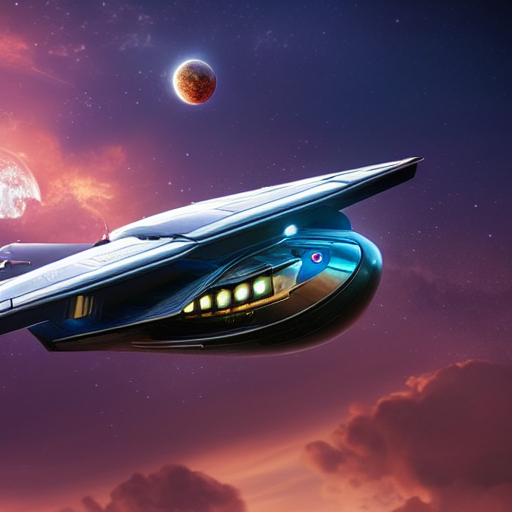

In [ ]:
# prompt_pt = "crie um guaxinim piloto de naves espaciais. Ele está pilotando sua nave espacial e passando pela terra. Se inspira no Rocket, personagem dos guardiões da galáxia da marvel dc. Cria em Arte digital, 4k, detalhado"
# image = gerar_imagem(prompt_pt)

Traduzido: Create a spaceship pilot raccoon. He is flying his spaceship and passing by the earth. It is inspired by Rocket, a character from Marvel DC's Guardians of the Galaxy. Create in digital art, 4k, detailed


  0%|          | 0/30 [00:00<?, ?it/s]

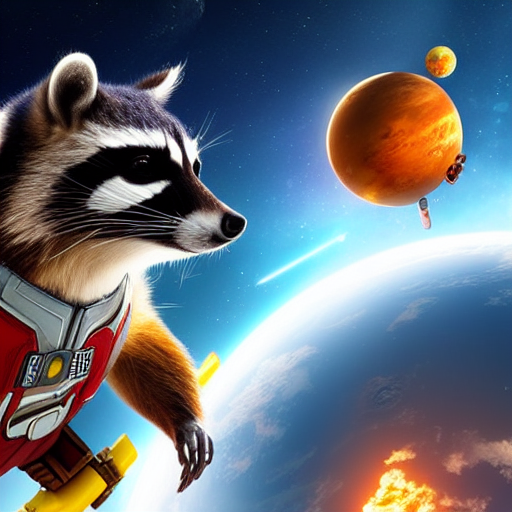

In [ ]:
from deep_translator import GoogleTranslator

def traduzir_prompt(texto_pt):
    return GoogleTranslator(source='pt', target='en').translate(texto_pt)

# Escrevendo em PT
prompt_pt = "crie um guaxinim piloto de naves espaciais. Ele está pilotando sua nave espacial e passando pela terra. Se inspira no Rocket, personagem dos guardiões da galáxia da marvel dc. Cria em Arte digital, 4k, detalhado"

# Traduzindo para EN (Stable Diffusion 1.5 funciona melhor em EN)
prompt_en = traduzir_prompt(prompt_pt)
print(f"Traduzido: {prompt_en}")

image = pipe(
    prompt=prompt_en,
    negative_prompt="ugly, deformed, noisy, blurry, distorted, out of focus, bad anatomy, extra limbs, poorly drawn face, poorly drawn hands, missing fingers",
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]

display(image)

  0%|          | 0/30 [00:00<?, ?it/s]

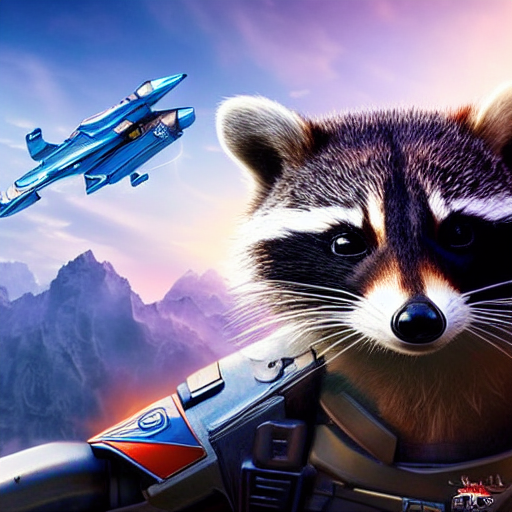

In [ ]:
#Melhoramento prompt positivo
prefix = "masterpiece, best quality, highly detailed, sharp focus, "
prompt_en = prefix + traduzir_prompt(prompt_pt)
negative_prompt = "ugly, deformed, noisy, blurry, distorted, out of focus, bad anatomy, extra limbs, poorly drawn face, poorly drawn hands, missing fingers"

# pipe limpo
image = pipe(
    prompt=prompt_en,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]

display(image)

In [ ]:
# Liberando VRAM antes do upscaler
del pipe
torch.cuda.empty_cache()
print(f"VRAM livre: {torch.cuda.memory_reserved(0)/1024**2:.0f}MB reservados")

VRAM livre: 22MB reservados


In [ ]:
# upscaler = StableDiffusionUpscalePipeline.from_pretrained(
#     "stabilityai/stable-diffusion-x4-upscaler",
#     torch_dtype=torch.float16
# ).to("cuda")

# image_hd = upscaler(prompt=prompt_en, image=image).images[0]
# image_hd.save("resultado_4k.png")
# display(image_hd)

# print("Upscaling concluído!")

VRAM livre: 12666MB
Imagem salva em alta resolução!
Drive: /content/drive/MyDrive/Minha-IA-Generativa/resultado_4k.png


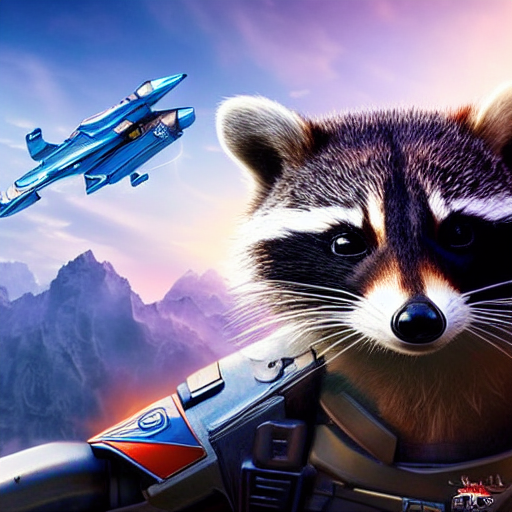

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(f"VRAM livre: {(torch.cuda.mem_get_info()[0]/1024**2):.0f}MB")

# Upscaling e salvando resultado
from IPython.display import display
import os

# Fazendo o upscaling
# image_hd = upscaler(
#     prompt=prompt_en,
#     image=image,
#     num_inference_steps=20,
# ).images[0]

# Salvando localmente no Colab
image.save("resultado_4k.png")

# Salvando no Google Drive também
drive_path = "/content/drive/MyDrive/Minha-IA-Generativa/resultado_4k.png"
image.save(drive_path)

print(f"Imagem salva em alta resolução!")
print(f"Drive: {drive_path}")

# Exibindo o resultado
display(image)

Traduzido: masterpiece, best quality, highly detailed, sharp focus, Creates the image of a reflective man beneath a tree. The hand of God appearing in the background. It is inspired by the format of the film The Boy, the Mole, the Fox and the Horse, from appletv. Create in digital art, 4k, detailed


  0%|          | 0/30 [00:00<?, ?it/s]

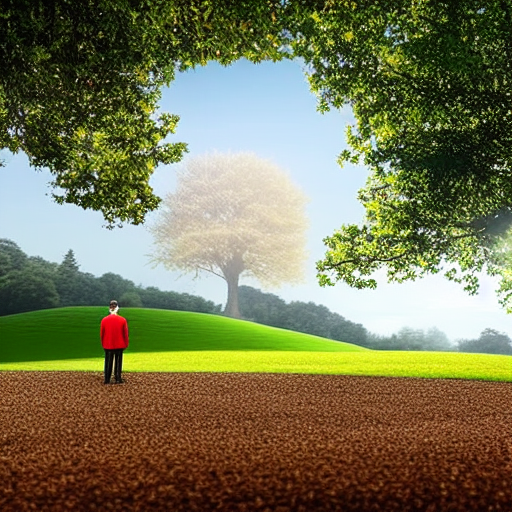

In [ ]:
from deep_translator import GoogleTranslator

def traduzir_prompt(texto_pt):
    return GoogleTranslator(source='pt', target='en').translate(texto_pt)

# Prompt em PT
prompt_pt = "Cria a imagem de um homem reflexivo embaixo de uma árvore. A mão de Deus aparecendo de fundo. Se inspira no formato do filme O Menino, a Toupeira, a Raposa e o Cavalo, da appletv. Cria em Arte digital, 4k, detalhado"

# Traduz e adiciona prefix
prefix = "masterpiece, best quality, highly detailed, sharp focus, "
prompt_en = prefix + traduzir_prompt(prompt_pt)
negative_prompt = "ugly, deformed, noisy, blurry, distorted, out of focus, bad anatomy, extra limbs, poorly drawn face, poorly drawn hands, missing fingers"

print(f"Traduzido: {prompt_en}")

# Gera imagem
image = pipe(
    prompt=prompt_en,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]

display(image)

In [ ]:
# from deep_translator import GoogleTranslator

# def traduzir_prompt(texto_pt):
#     return GoogleTranslator(source='pt', target='en').translate(texto_pt)

# # Escrevendo em PT
# prompt_pt = "Um cachorro herói voando no espaço, em busca de um petisco, arte digital, 4k, detalhado"

# # Traduzindo para EN (Stable Diffusion 1.5 funciona melhor em EN)
# prompt_en = traduzir_prompt(prompt_pt)
# print(f"Traduzido: {prompt_en}")

# image = pipe(
#     prompt=prompt_en,
#     negative_prompt="blurry, bad quality, distorted, ugly",
#     num_inference_steps=30,
#     guidance_scale=7.5,
# ).images[0]

# display(image)

In [ ]:
# from deep_translator import GoogleTranslator

# def traduzir_prompt(texto_pt):
#     return GoogleTranslator(source='pt', target='en').translate(texto_pt)

# # Escrevendo em PT
# prompt_pt = "Um cachorro herói parecido com o Kripto de capa voando no espaço, arte digital, 4k, ótima qualidade"

# # Traduzindo para EN (Stable Diffusion 1.5 funciona melhor em EN)
# prompt_en = traduzir_prompt(prompt_pt)
# print(f"Traduzido: {prompt_en}")

# image = pipe(
#     prompt=prompt_en,
#     negative_prompt="blurry, bad quality, distorted, ugly",
#     num_inference_steps=30,
#     guidance_scale=7.5,
# ).images[0]

# display(image)

In [ ]:
# from deep_translator import GoogleTranslator

# def traduzir_prompt(texto_pt):
#     return GoogleTranslator(source='pt', target='en').translate(texto_pt)

# # Escrevendo em PT
# prompt_pt = "Um homem resurgindo de uma fase ruim e caminhando vitorioso, agradecido, arte digital, 4k, ótima qualidade, detalhado"

# # Traduzindo para EN (Stable Diffusion 1.5 funciona melhor em EN)
# prompt_en = traduzir_prompt(prompt_pt)
# print(f"Traduzido: {prompt_en}")

# image = pipe(
#     prompt=prompt_en,
#     negative_prompt="blurry, bad quality, distorted, ugly",
#     num_inference_steps=30,
#     guidance_scale=7.5,
# ).images[0]

# display(image)

In [ ]:
# from deep_translator import GoogleTranslator

# def traduzir_prompt(texto_pt):
#     return GoogleTranslator(source='pt', target='en').translate(texto_pt)

# # Escrevendo em PT
# prompt_pt = "Um homem em um computador, desenvolvendo seus programas, digitando códigos, arte digital, 4k, ótima qualidade, detalhado"

# # Traduzindo para EN (Stable Diffusion 1.5 funciona melhor em EN)
# prompt_en = traduzir_prompt(prompt_pt)
# print(f"Traduzido: {prompt_en}")

# image = pipe(
#     prompt=prompt_en,
#     negative_prompt="blurry, bad quality, distorted, ugly",
#     num_inference_steps=30,
#     guidance_scale=7.5,
# ).images[0]

# display(image)

In [ ]:
#Conectando Ngrok (opção frustrada)
#!ngrok config add-authtoken Suprimido

In [ ]:
from pyngrok import conf
conf.get_default().region = "us"

In [ ]:
import nest_asyncio
import uvicorn
import subprocess
import threading
import time
import os
import re
from fastapi import FastAPI, Request, Response
from fastapi.responses import JSONResponse
from pydantic import BaseModel
import torch, base64, io

nest_asyncio.apply()
os.system("fuser -k 8000/tcp")

app = FastAPI()

@app.middleware("http")
async def add_cors_headers(request: Request, call_next):
    if request.method == "OPTIONS":
        return Response(status_code=200, headers={
            "Access-Control-Allow-Origin": "*",
            "Access-Control-Allow-Methods": "GET, POST, OPTIONS",
            "Access-Control-Allow-Headers": "*",
        })
    response = await call_next(request)
    response.headers["Access-Control-Allow-Origin"] = "*"
    return response

class GenerateRequest(BaseModel):
    prompt: str
    negative_prompt: str = "blurry, bad quality, distorted"
    width: int = 512
    height: int = 512
    num_inference_steps: int = 30
    guidance_scale: float = 7.5

@app.post("/generate")
def generate(req: GenerateRequest):
    image = pipe(
        prompt=req.prompt,
        negative_prompt=req.negative_prompt,
        width=req.width,
        height=req.height,
        num_inference_steps=req.num_inference_steps,
        guidance_scale=req.guidance_scale,
    ).images[0]
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    img_base64 = base64.b64encode(buffer.getvalue()).decode()
    return JSONResponse(
        content={"image": img_base64, "prompt_used": req.prompt},
        headers={
            "Access-Control-Allow-Origin": "*",
            "Access-Control-Allow-Methods": "POST, OPTIONS",
            "Access-Control-Allow-Headers": "*",
        }
    )

@app.options("/generate")
def options_generate():
    return JSONResponse(
        content={},
        headers={
            "Access-Control-Allow-Origin": "*",
            "Access-Control-Allow-Methods": "POST, OPTIONS",
            "Access-Control-Allow-Headers": "*",
        }
    )

@app.get("/health")
def health():
    return {"status": "online", "device": "cuda" if torch.cuda.is_available() else "cpu"}

# Sobe o servidor
threading.Thread(target=uvicorn.run, kwargs={"app": app, "host": "0.0.0.0", "port": 8000}).start()
time.sleep(3)

# Túnel Cloudflare
proc = subprocess.Popen(
    ['cloudflared', 'tunnel', '--url', 'http://localhost:8000',
     '--http-host-header', 'localhost:8000'],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

for line in proc.stdout:
    line = line.decode()
    match = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', line)
    if match:
        url = match.group(0)
        print(f"API rodando em: {url}")
        print(f"Cole essa URL no frontend do Netlify!")
        break

INFO:     Started server process [9361]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


API rodando em: https://guarantee-deposit-economy-feel.trycloudflare.com
Cole essa URL no frontend do Netlify!


In [ ]:
# Salvando alterações no GitHub
import os
os.chdir('/content/Generative-AI-Lab')

TOKEN = "Suprimido"
!git remote set-url origin https://suprimido@github.com/Jesse-DataDriven/Generative-AI-Lab.git

!git add .
!git commit -m "Atualizando notebook"
!git push
print("✅ Enviado para o GitHub!")

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
✅ Enviado para o GitHub!


In [ ]:
print(url)

https://guarantee-deposit-economy-feel.trycloudflare.com
